=== 下载 Baseline 测试图片 ===
下载失败 https://images.unsplash.com/photo-1581091226825-a6a63e27c4df: 404 Client Error: Not Found for url: https://images.unsplash.com/photo-1581091226825-a6a63e27c4df

=== 初始化 GroundingDINO 模型 ===
final text_encoder_type: /home/chendawww/workspace/hf/bert-base-uncased


Some weights of the model checkpoint at /home/chendawww/workspace/hf/bert-base-uncased were not used when initializing BertModel: ['cls.seq_relationship.bias', 'cls.predictions.transform.dense.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.decoder.weight', 'cls.predictions.transform.LayerNorm.bias', 'cls.seq_relationship.weight', 'cls.predictions.bias', 'cls.predictions.transform.dense.weight']
- This IS expected if you are initializing BertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


[GroundingDINODetector] 模型加载完成 (设备: cuda)
[GroundingDINODetector] 预热完成，耗时 0.75s

=== 开始 Baseline 推理测试 (Prompt: 'bag . cup . chair .') ===

处理: img_00.jpg | 形状: (853, 1280, 3)


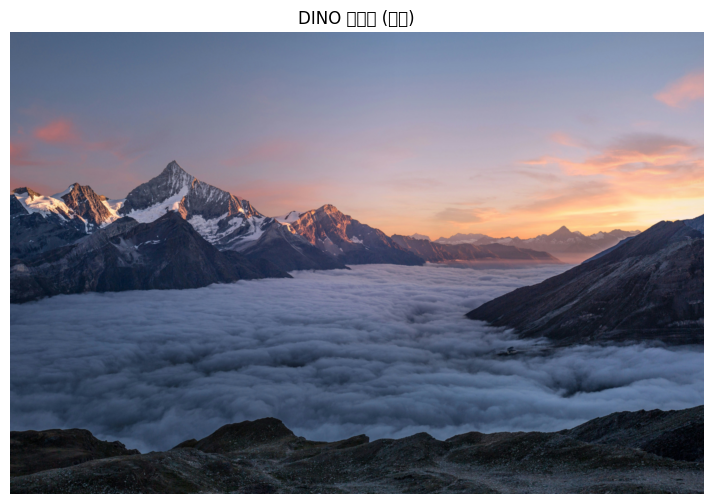

/home/chendawww/Software/anaconda3/envs/ros2/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 21518 (\N{CJK UNIFIED IDEOGRAPH-540E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/chendawww/Software/anaconda3/envs/ros2/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 32467 (\N{CJK UNIFIED IDEOGRAPH-7ED3}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/chendawww/Software/anaconda3/envs/ros2/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 26524 (\N{CJK UNIFIED IDEOGRAPH-679C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


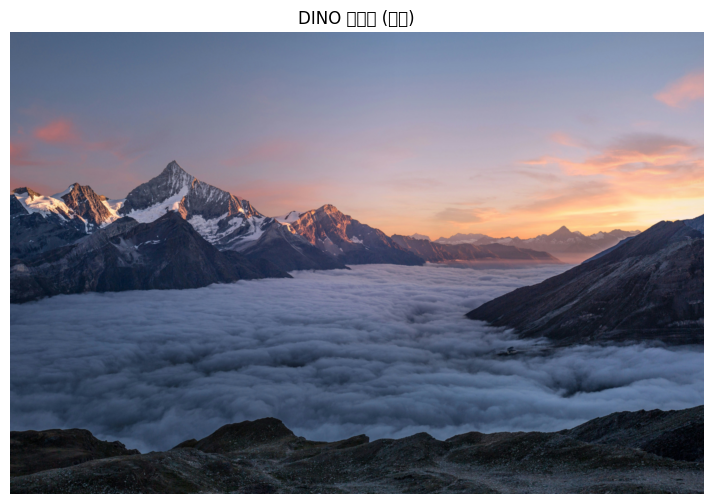

  -> 结果: 找到 0 个目标, 耗时 0.327s

处理: img_02.jpg | 形状: (853, 1280, 3)


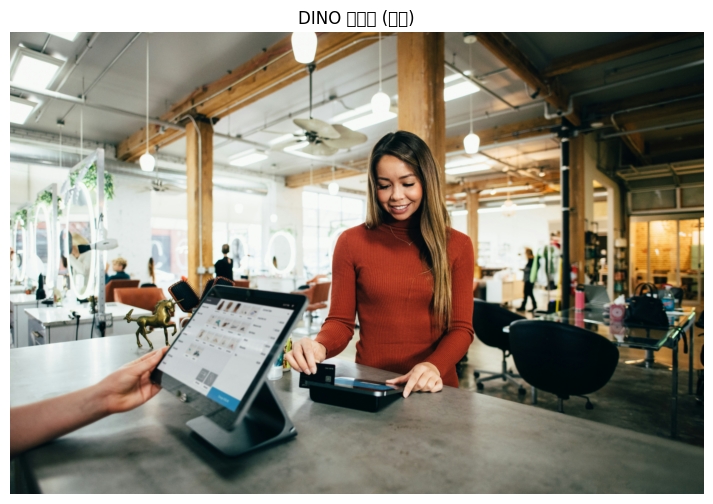

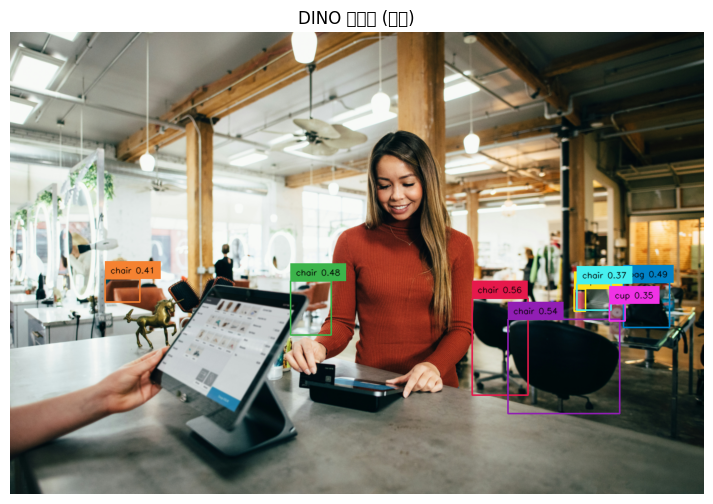

  -> 结果: 找到 8 个目标, 耗时 0.308s
     - chair (置信度: 0.56)
     - chair (置信度: 0.48)
     - cup (置信度: 0.44)
     - bag (置信度: 0.49)
     - chair (置信度: 0.41)
     - chair (置信度: 0.54)
     - chair (置信度: 0.37)
     - cup (置信度: 0.35)


In [3]:
# perception/perception/groundingDINO/test_detector.py
import os
import requests
import time
import numpy as np
from PIL import Image

from detector import GroundingDINODetector

# ---------- 配置 ----------
BASELINE_IMAGE_URLS = [
    "https://images.unsplash.com/photo-1506905925346-21bda4d32df4",
    "https://images.unsplash.com/photo-1581091226825-a6a63e27c4df",
    "https://images.unsplash.com/photo-1556740738-b6a63e27c4df",
]
SAVE_DIR = "./test_baseline_images"

GD_CONFIG = "/home/chendawww/workspace/GroundingDINO/groundingdino/config/GroundingDINO_SwinT_OGC.py"
GD_CHECKPOINT = "/home/chendawww/workspace/GroundingDINO/weights/groundingdino_swint_ogc.pth"
TEXT_PROMPT = "bag . cup . chair ."
BOX_THRESHOLD = 0.35
TEXT_THRESHOLD = 0.25


# ---------- 工具（照抄你之前的逻辑） ----------
def download_to_local(url: str, save_path: str) -> bool:
    try:
        r = requests.get(url, timeout=15)
        r.raise_for_status()
        with open(save_path, "wb") as f:
            f.write(r.content)
        return True
    except Exception as e:
        print(f"下载失败 {url}: {e}")
        return False


def load_image_from_local(path: str, max_size=1280):
    """照抄你之前的实现，返回 RGB numpy (H,W,3)"""
    img = Image.open(path).convert("RGB")
    w, h = img.size
    if max(w, h) > max_size:
        scale = max_size / max(w, h)
        img = img.resize((int(w * scale), int(h * scale)), Image.BILINEAR)
    return np.array(img)  # RGB numpy


# ---------- 主测试 ----------
def test_groundingdino_detector():
    os.makedirs(SAVE_DIR, exist_ok=True)

    # 1. 准备 Baseline 图片
    print("=== 下载 Baseline 测试图片 ===")
    local_paths = []
    for i, url in enumerate(BASELINE_IMAGE_URLS):
        fname = f"img_{i:02d}.jpg"
        path = os.path.join(SAVE_DIR, fname)
        if os.path.isfile(path):
            local_paths.append(path)
            continue
        if download_to_local(url, path):
            local_paths.append(path)

    # 2. 初始化模型
    print("\n=== 初始化 GroundingDINO 模型 ===")
    detector = GroundingDINODetector(GD_CONFIG, GD_CHECKPOINT)

    # 可选：预热（和你的脚本一致）
    if local_paths:
        dummy_rgb = load_image_from_local(local_paths[0])
        detector._warmup(dummy_rgb)

    # 3. 逐张推理（照抄你的主流程）
    print(f"\n=== 开始 Baseline 推理测试 (Prompt: '{TEXT_PROMPT}') ===")
    for path in local_paths:
        img_np_rgb = load_image_from_local(path)
        print(f"\n处理: {os.path.basename(path)} | 形状: {img_np_rgb.shape}")

        detector.show_image(img_np_rgb, title="DINO 识别前 (原图)")
        result = detector.detect(
            image_np_rgb=img_np_rgb,
            text_prompt=TEXT_PROMPT,
            box_threshold=BOX_THRESHOLD,
            text_threshold=TEXT_THRESHOLD,
        )
        detector.show_image(result["annotated_image"], title="DINO 识别后 (结果)")
        
        if result["status"] == "success":
            boxes = result["boxes"]
            n = len(boxes) if boxes is not None and len(boxes) > 0 else 0
            print(f"  -> 结果: 找到 {n} 个目标, 耗时 {result['inference_time_s']:.3f}s")
            if n > 0:
                for phrase, score in zip(result["phrases"], result["logits"]):
                    print(f"     - {phrase.strip('. ')} (置信度: {score:.2f})")
        else:
            print(f"  -> 失败: {result['detail']}")


if __name__ == "__main__":
    test_groundingdino_detector()
